In [2]:
import sys
import warnings

sys.path.append("../..")
warnings.filterwarnings(action="ignore")

In [3]:
# explicitly set the PROJ data directory to ensure pyproj can resolve EPSG codes correctly.
from pyproj.datadir import set_data_dir

set_data_dir("/opt/anaconda3/envs/claymodel/share/proj")

In [4]:
# import libs

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import glob
import torch
from einops import rearrange
from claymodel.datamodule import ClayDataModule
from claymodel.module import ClayMAEModule

In [5]:
data_dir = "./cubes"
checkpoint_path = "./clay-v1.5.ckpt"
metadata_path = "./configs/metadata.yaml"
chip_size = 256
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL

In [6]:
# visualize embeddings from model
# neither mask the input image or shuffle the patches

module = ClayMAEModule.load_from_checkpoint(
    checkpoint_path=checkpoint_path,
    model_size="large",
    metadata_path=metadata_path,
    dolls=[16, 32, 64, 128, 256, 768, 1024],
    doll_weights=[1, 1, 1, 1, 1, 1, 1],
    mask_ration=0.0,
    shuffle=False,
)

module.eval()

ClayMAEModule(
  (model): ClayMAE(
    (teacher): VisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (pos_drop): Dropout(p=0.0, inplace=False)
      (patch_drop): Identity()
      (norm_pre): Identity()
      (blocks): Sequential(
        (0): Block(
          (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (attn): Attention(
            (qkv): Linear(in_features=1024, out_features=3072, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=1024, out_features=1024, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): Mlp(
    

In [7]:
# Distributed setup

import os
import torch.distributed as dist

if not dist.is_initialized():
    os.environ["MASTER_ADDR"] = "localhost"
    os.environ["MASTER_PORT"] = "12356"
    dist.init_process_group("gloo", rank=0, world_size=1)

DATAMODULE

In [16]:
import os
import shutil

BASE_DIR = "./data3/naip"
INC_DIR = "./data/inc_cubes_naip"
os.makedirs(INC_DIR, exist_ok=True)

# Find all .npz files
npz_files = sorted(glob.glob(os.path.join(BASE_DIR, "*.npz")))

print(f"Found {len(npz_files)} .npz files")

# Keep first 256, move the rest
keep = npz_files[:384]
move = npz_files[384:]

print(f"Keeping {len(keep)} files in {BASE_DIR}")
print(f"Moving {len(move)} files to {INC_DIR}")

for f in move:
    fname = os.path.basename(f)
    dest = os.path.join(INC_DIR, fname)
    shutil.move(f, dest)
    print(f"→ Moved {fname} to inc_cubes_naip")

print("\n✅ Done: 384 files kept, rest moved.")

Found 509 .npz files
Keeping 384 files in ./data3/naip
Moving 125 files to ./data/inc_cubes_naip
→ Moved cube_444.npz to inc_cubes_naip
→ Moved cube_445.npz to inc_cubes_naip
→ Moved cube_446.npz to inc_cubes_naip
→ Moved cube_447.npz to inc_cubes_naip
→ Moved cube_448.npz to inc_cubes_naip
→ Moved cube_449.npz to inc_cubes_naip
→ Moved cube_45.npz to inc_cubes_naip
→ Moved cube_450.npz to inc_cubes_naip
→ Moved cube_451.npz to inc_cubes_naip
→ Moved cube_452.npz to inc_cubes_naip
→ Moved cube_453.npz to inc_cubes_naip
→ Moved cube_454.npz to inc_cubes_naip
→ Moved cube_455.npz to inc_cubes_naip
→ Moved cube_456.npz to inc_cubes_naip
→ Moved cube_457.npz to inc_cubes_naip
→ Moved cube_458.npz to inc_cubes_naip
→ Moved cube_459.npz to inc_cubes_naip
→ Moved cube_46.npz to inc_cubes_naip
→ Moved cube_460.npz to inc_cubes_naip
→ Moved cube_461.npz to inc_cubes_naip
→ Moved cube_462.npz to inc_cubes_naip
→ Moved cube_463.npz to inc_cubes_naip
→ Moved cube_464.npz to inc_cubes_naip
→ Moved 

In [9]:
for npz_file in Path("./cubes").glob("*.npz"):
    sample = np.load(npz_file)
    print(f"{npz_file.name}: keys = {list(sample.keys())}")
    print(f"pixels shape = {sample['meta'].shape}")
    # print(f"week_norm = {sample['week_norm'].shape}")
    break  # just inspect one for now

S2B_43RGP_20240826_0_L2A.npz: keys = ['cube', 'meta']


ValueError: Object arrays cannot be loaded when allow_pickle=False

In [10]:
import os
import glob
import shutil

BASE_DIR = "./cubes"

cube_files = sorted(glob.glob(os.path.join(BASE_DIR, "*.npz")))

print(f"Found {len(cube_files)} cube files")

Found 105 cube files


In [12]:
# load claydatamodule

# for model trainings, we stack chips from one sensor into batches of size 128.
# This reduces the num_workers we need to load the batches and speeds up the training process.
# although the batch size is 1, the data modeule reads batch of size 128.

dm = ClayDataModule(
    data_dir=data_dir,
    metadata_path=metadata_path,
    platforms=["sentinel-2-l2a"],
    size=chip_size,
    batch_size=1,
    num_workers=1,
)

dm.setup(stage="fit")

Total number of chips: 105


In [13]:
# ok to use either train or val dataloader

dl = iter(dm.train_dataloader())

In [14]:
sentinel = next(dl)

KeyError: Caught KeyError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/opt/anaconda3/envs/claymodel/lib/python3.11/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/claymodel/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/claymodel/lib/python3.11/site-packages/torch/utils/data/_utils/fetch.py", line 52, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/Users/neerajkaroshi/Desktop/clay/model/claymodel/datamodule.py", line 69, in __getitem__
    pixels = chip["pixels"].astype(np.float32)
             ~~~~^^^^^^^^^^
  File "/opt/anaconda3/env

In [22]:
naip = next(dl)

In [23]:
# Assuming `naip` is already loaded as a dict-like object from your .npz
print(
    f"{naip['platform'][0]:<15}",
    naip["pixels"].shape,
    naip["time"].shape,
    naip["latlon"].shape,
)

naip            torch.Size([128, 4, 256, 256]) torch.Size([128, 4]) torch.Size([128, 4])


INPUT

In [24]:
def create_batch(chips, wavelengths, gsd, device):
    batch = {}

    batch["pixels"] = chips["pixels"].to(device)
    batch["time"] = chips["time"].to(device)
    batch["latlon"] = chips["latlon"].to(device)

    batch["waves"] = torch.tensor(wavelengths)
    batch["gsd"] = torch.tensor(gsd)

    return batch

In [25]:
# creating batch for "NAIP"

platform = "naip"
metadata = dm.metadata[platform]
wavelengths = list(metadata.bands.wavelength.values())
gsd = metadata.gsd

In [27]:
batch_naip = create_batch(naip, wavelengths, gsd, device)

FORWARD PASS - Clay Encoder

In [28]:
with torch.no_grad():
    unmsk_patch_naip, *_ = module.model.encoder(batch_naip)

In [34]:
unmsk_patch_naip.shape

torch.Size([128, 257, 1024])

In [40]:
print(type(module.model))
# print(module.model)
print(module.model.encoder)

<class 'claymodel.model.ClayMAE'>
Encoder(
  (patch_embedding): DynamicEmbedding(
    (weight_generator): WavesTransformer(
      (encoder): TransformerEncoder(
        (layers): ModuleList(
          (0): TransformerEncoderLayer(
            (self_attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
            )
            (linear1): Linear(in_features=128, out_features=2048, bias=True)
            (dropout): Dropout(p=0, inplace=False)
            (linear2): Linear(in_features=2048, out_features=128, bias=True)
            (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
            (dropout1): Dropout(p=0, inplace=False)
            (dropout2): Dropout(p=0, inplace=False)
          )
        )
      )
      (fc_weight): Linear(in_features=128, out_features=65536, bias=True)
      (fc_bias): Linear(in_features=128, ou

In [45]:
def denormalize_image(normalized_images, means, stds):
    "Denormalizes an image using its mean & std"
    means = np.array(means)
    means = np.array(means).reshape(1, -1, 1, 1)
    stds = np.array(stds)
    stds = np.array(stds).reshape(1, -1, 1, 1)

    denormalized_images = normalized_images * stds + means
    return denormalized_images

In [47]:
naip_mean = list(dm.metadata["naip"].bands.mean.values())
naip_std = list(dm.metadata["naip"].bands.std.values())

batch_naip_pixels = batch_naip["pixels"].detach().cpu().numpy()
batch_naip_pixels = denormalize_image(batch_naip_pixels, naip_mean, naip_std)
batch_naip_pixels = batch_naip_pixels.astype(np.uint8)

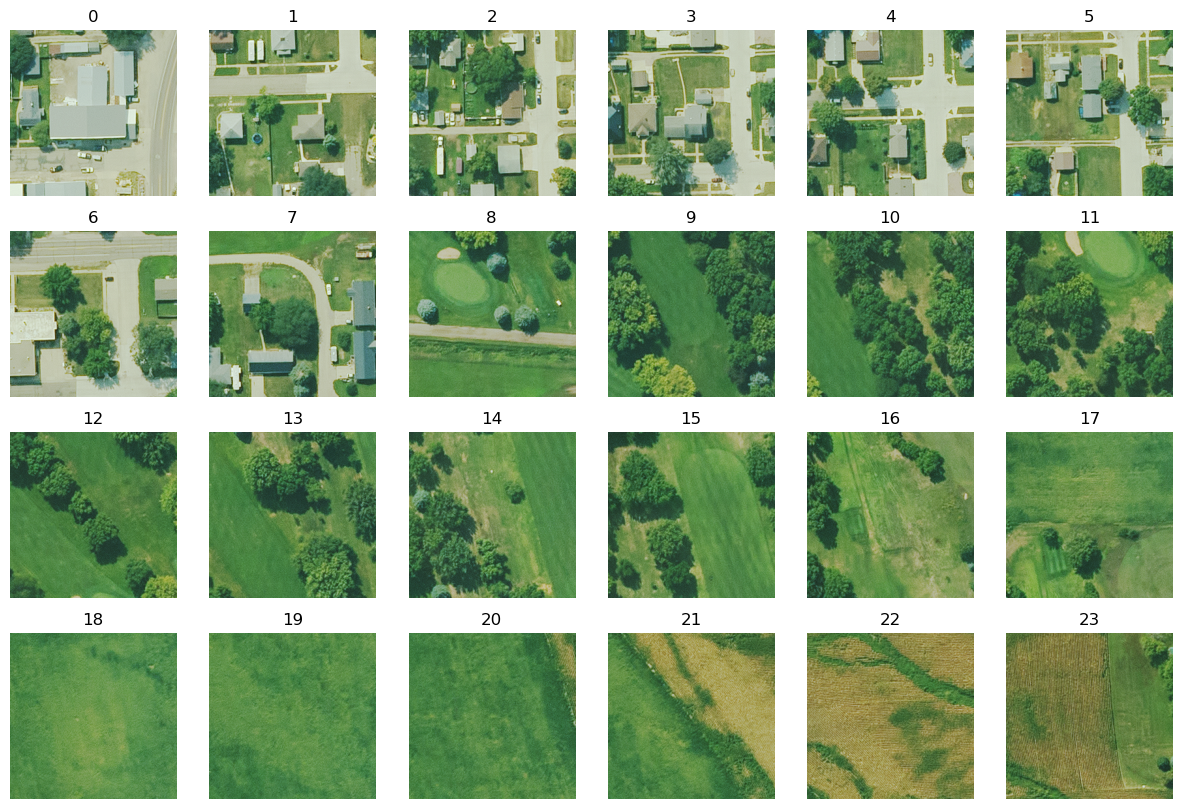

In [48]:
# ploting first 24 chips fed to model

fig, axs = plt.subplots(4, 6, figsize=(15, 10))

for idx, ax in enumerate(axs.flatten()):
    ax.imshow(batch_naip_pixels[idx, :3, ...].transpose(1, 2, 0))
    ax.set_axis_off()
    ax.set_title(idx)

Rearrange the embeddings from the Clay Encoder back to images.

Embeddings are of shape: batch x (1:cls_token + 1024:patches) x 1024:embedding dimension
# 
1024:patches can be transformed into images of shape 32 x 32 
#
1024:embedding dimension can be moved as channel dimension 
#
Here, each embedding dims represents a particular unique feature of the chip

In [ ]:
# unmsk_embed = rearrange(
##    unmsk_patch_naip[:, 1:, :].detach().cpu().numpy(), "b (h w) d-> b d h w", h=32, w=32
# )

In [49]:
unmsk_embed = rearrange(
    unmsk_patch_naip[:, 1:, :].detach().cpu().numpy(),
    "b (h w) d -> b d h w",
    h=16,
    w=16,
)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

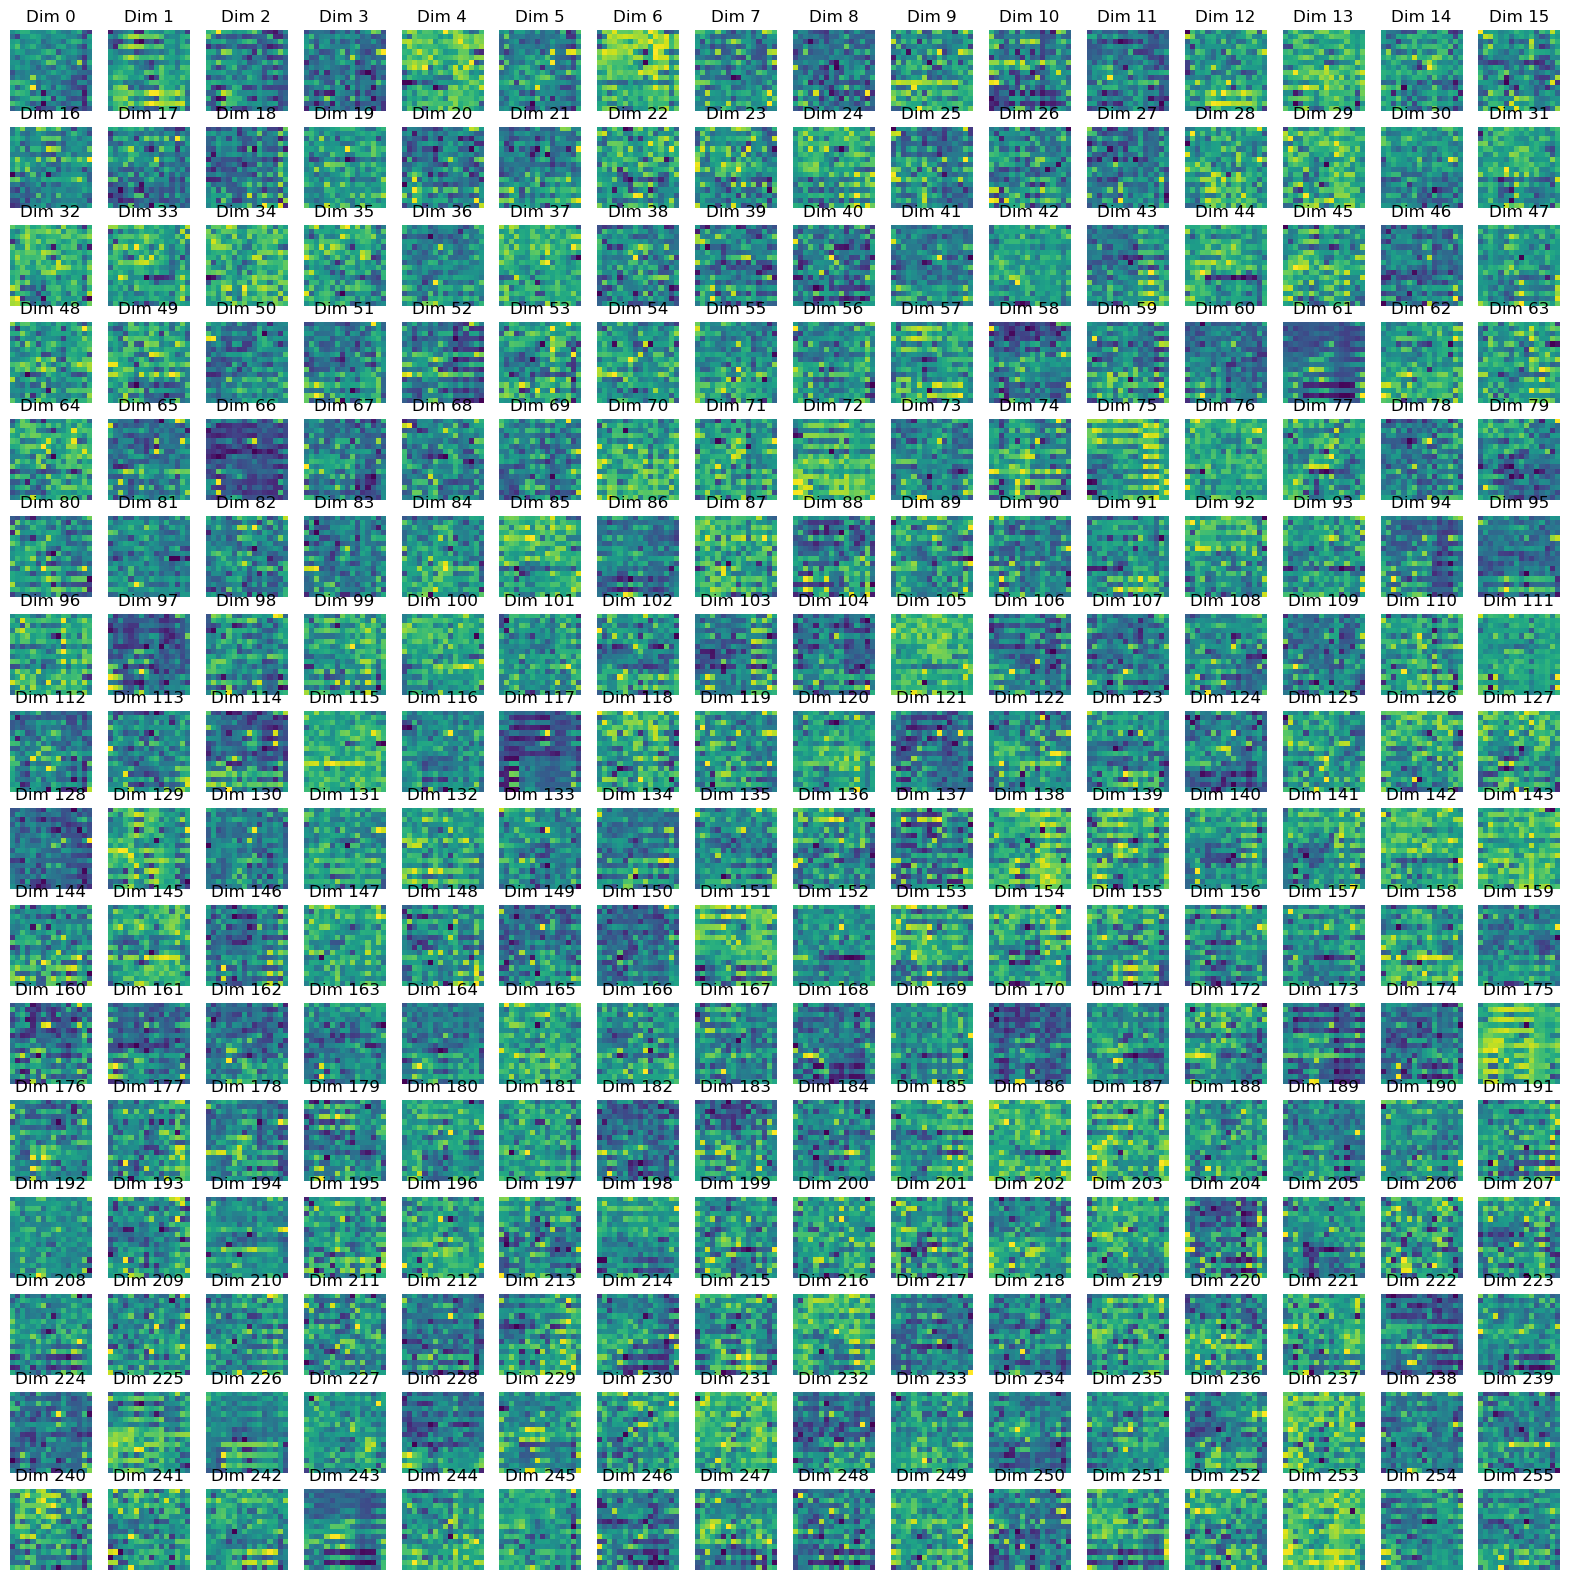

In [50]:
# Pick a NAIP chip from the first 24 plotted above and visualize what each of the embedding dims look like for it.
# To prevent overflowing the notebook, lets plot the first 256 embedding dimensions.

embed = unmsk_embed[0]
fig, axs = plt.subplots(16, 16, figsize=(20, 20))

for idx, ax in enumerate(axs.flatten()):
    ax.imshow(embed[idx, :, :], cmap="viridis")
    ax.set_axis_off()
    ax.set_title(f"Dim {idx}")

plt.tight_layout

As we see above, each embedding dimension represents a feature of the chip. Some are simple & easy to interpret for human eyes like edges, patterns, features like land & water - while some are more complex.
Now, lets pick one embedding from the 1024 plotted above & visualize the same for all the chips.



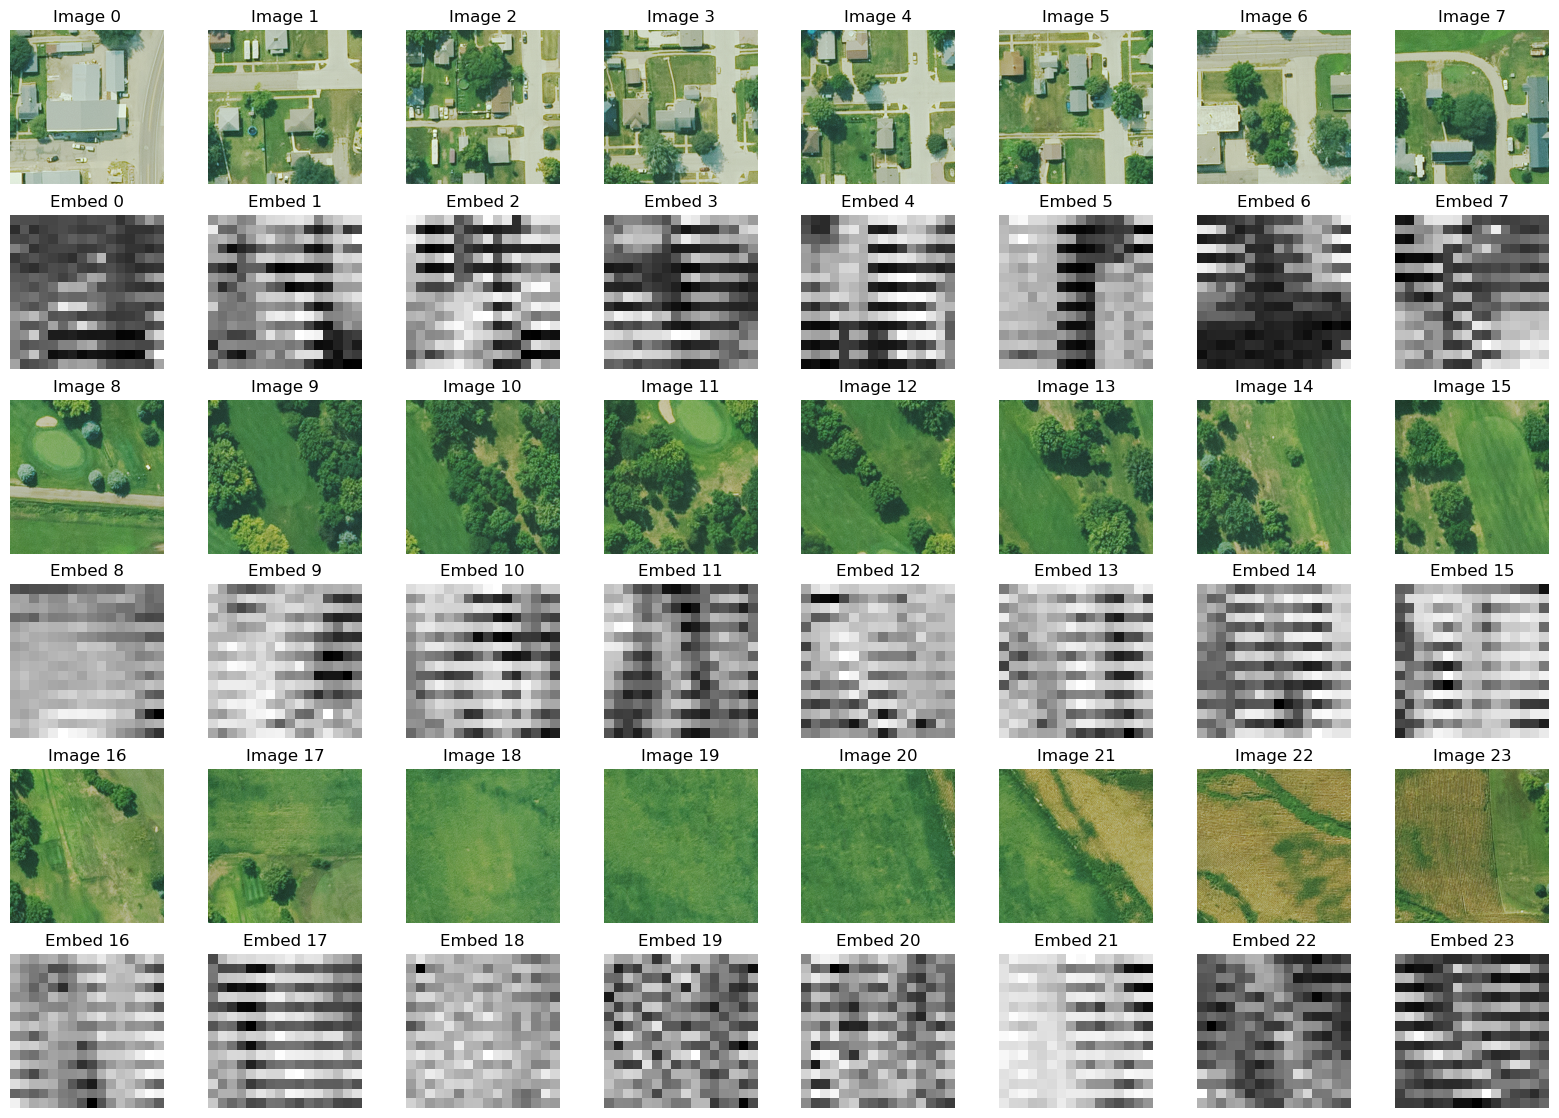

In [51]:
fig, axs = plt.subplots(6, 8, figsize=(20, 14))
embed_dim = 61  # pick any embedding dimension

for i in range(0, 6, 2):
    for j in range(8):
        idx = (i // 2) * 8 + j
        axs[i][j].imshow(batch_naip_pixels[idx, :3, ...].transpose(1, 2, 0))
        axs[i][j].set_axis_off()
        axs[i][j].set_title(f"Image {idx}")
        embed = unmsk_embed[idx]
        axs[i + 1][j].imshow(embed[embed_dim], cmap="gray")
        axs[i + 1][j].set_axis_off()
        axs[i + 1][j].set_title(f"Embed {idx}")